# Training Examples (Single & Parallel)

This notebook shows how to use `train()` and `train_parallel()` from `graphallocbench.train_utils.general` with a **lightweight** config for quick smoke tests.
It writes a temporary small training config (very low timesteps) so you can verify the pipeline without long runs.

In [ ]:
# Optional: ensure repo root on sys.path if running without installation
import sys, os, pathlib
repo_root = pathlib.Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('Using repo root:', repo_root)

In [ ]:
# Imports
import os, yaml, time, random, torch
from graphallocbench.train_utils.general import train, train_parallel
from graphallocbench.constants import ALLOWED_DEVICES
from pathlib import Path
print('ALLOWED_DEVICES:', ALLOWED_DEVICES)

## 1. Create a minimal quick training config
This keeps steps tiny so it finishes fast. Adjust values for real experiments.
Required keys (mirrors what `train()` expects):
- env_name
- scalarization_method, smoothness
- architecture_idx (index into architectures registry)
- entropy (ent_coef), lr, n_steps, n_epochs, target_kl, clip_range
- total_timesteps
We'll use an existing small environment problem file (e.g. `problem_0`).

In [ ]:
quick_cfg = {
    'env_name': 'problem_0',  # must exist under config/problems/
    'scalarization_method': 'smooth_tchebycheff',
    'smoothness': 0.01,
    'architecture_idx': 0,  # typically MLP baseline
    'entropy': 0.01,
    'lr': 1e-4,
    'n_steps': 128,
    'n_epochs': 5,
    'target_kl': None,
    'clip_range': 0.2,
    'total_timesteps': 100000,  # very small for demo
}
demo_dir = Path('train_config/demo'); demo_dir.mkdir(parents=True, exist_ok=True)
demo_cfg_path = demo_dir / 'quick_problem_0.yml'
with open(demo_cfg_path, 'w') as f: yaml.safe_dump(quick_cfg, f)
print('Wrote config to', demo_cfg_path.resolve())

## 2. Single training run
Uses `WANDB_MODE=dryrun` so Weights & Biases doesn't require a network call. Remove that env var for real logging.

In [ ]:
# Single training example (fast)
device = 'cuda:0' if (torch.cuda.is_available()) else 'cpu'
print('Using device:', device)
start = time.time()
train(str(demo_cfg_path), project_name='GraphAllocBench-Demo', device=device, seed=0)
print(f'Training finished in {time.time()-start:.2f}s')

## 3. Inspect saved artifacts
Models are saved under `models/<project_name>/arch-<idx>/<env_name>/<seed>/`.
We list what was produced by the quick run.

In [5]:
from pathlib import Path, PurePosixPath
model_root = Path('models/GraphAllocBench-Demo')
if model_root.exists():
    for p in model_root.rglob('*'):
        if p.is_file():
            print(p)
else:
    print('No model directory found yet.')

models/GraphAllocBench-Demo/arch-0/problem_0/0/model_step_100000.zip
models/GraphAllocBench-Demo/arch-0/problem_0/0/model_step_50000.zip


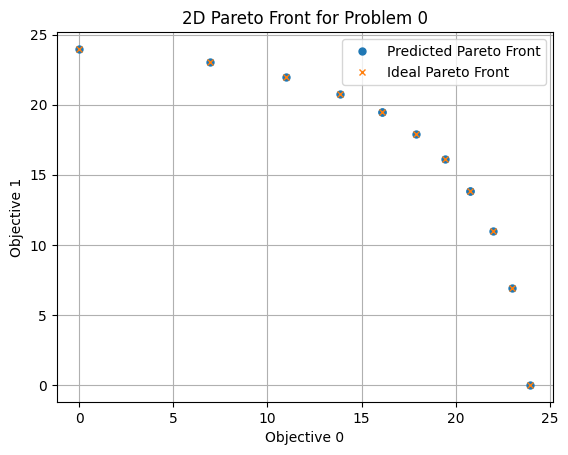

In [ ]:
from graphallocbench.city_env import CityPlannerEnv
from graphallocbench.evaluation import plot_2D_pareto_front

# Example: 2D Pareto plot for a small problem (needs trained model checkpoint path)
try:
    env = CityPlannerEnv('config/problems/problem_0.yml')
    plot_2D_pareto_front(env, model_path='models/GraphAllocBench-Demo/arch-0/problem_0/0/model_step_100000.zip')
except Exception as e:
    print('Skipping Pareto plot (missing model?):', e)

## 4. Parallel training example
Spawn multiple processes cycling over available devices. Keep timesteps tiny for a fast demonstration.

In [ ]:
# Prepare multiple (possibly identical) configs for parallel training
# We'll duplicate the same quick config path for two seeds.
parallel_configs = [str(demo_cfg_path)]
seeds = [0, 1]  # keep small
print('Launching parallel training ...')
train_parallel(parallel_configs, project_name='GraphAllocBench-Demo', seeds=seeds)
print('Parallel training complete.')

## 5. Tips for real runs
- Increase `total_timesteps`, `n_steps`, and `n_epochs`.
- Adjust `architecture_idx` to explore different model architectures.
- Remove `WANDB_MODE` or set your `WANDB_API_KEY` to log runs online.
- Use `train_parallel` with many configs (different envs or hyperparameters).
- Pin each process to a GPU by editing `ALLOWED_DEVICES` in `constants.py` or environment variable `CUDA_VISIBLE_DEVICES`.